In [ ]:
import sys
sys.path.insert(0, "../src")

import os
import time

import pandas as pd
import glob
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import graph_tool.all as gt

sns.set_theme(style="whitegrid", rc={"grid.color": "0.92", "grid.linewidth": 0.6})
%matplotlib inline

# Helpers

In [2]:
import glob
import re


def read_graphs_from_dir(dir_path, pattern="*.graphml"):
    """Load every GraphML file in `dir_path` into a dict.

    Parameters
    ----------
    dir_path : str
        Directory to search (non-recursive).
    pattern : str
        Glob pattern for the files to load.

    Returns
    -------
    dict[str, graph_tool.Graph]
        Keyed by file name without extension (e.g. "GB", "RU_0",
        "AT_anti_basic_income_flipped"), sorted by key. Each graph carries the
        `belief` vertex property and `weight` edge property saved at inference.
    """
    graphs = {}
    for path in sorted(glob.glob(os.path.join(dir_path, pattern))):
        name = os.path.splitext(os.path.basename(path))[0]
        graphs[name] = gt.load_graph(path)
    return graphs


def read_flipped_dims_from_dir(dir_path, key_prefix, pattern="flipped_dims_*.csv"):
    """Read the set of flipped belief dimensions for each sample.

    Each `flipped_dims_<i>.csv` (written by generate_alternate_coding.py) has a
    single `dimension` column listing the dimensions flipped in sample i.

    Parameters
    ----------
    dir_path : str
        Directory holding the flipped_dims_<i>.csv files.
    key_prefix : str
        Prefix for the returned keys (e.g. the country code), so keys match the
        corresponding networks from `read_graphs_from_dir`.

    Returns
    -------
    dict[str, list[str]]
        Keyed "<key_prefix>_<i>" -> list of flipped dimension names.
    """
    dims = {}
    for path in sorted(glob.glob(os.path.join(dir_path, pattern))):
        m = re.search(r"flipped_dims_(\d+)\.csv$", os.path.basename(path))
        if not m:
            continue
        i = int(m.group(1))
        dims[f"{key_prefix}_{i}"] = pd.read_csv(path)["dimension"].tolist()
    return dims


# Read data

In [3]:
# Networks inferred from the unchanged data (one per country).
# The *.graphml glob matches only the 23 country files here; the flipped/ and
# random_flip/ subdirectories are skipped.
UNCHANGED_DIR = "../output/networks"
unchanged_graphs = read_graphs_from_dir(UNCHANGED_DIR)

# Networks inferred after flipping the coding of ONE belief dimension
# (23 countries x 20 dimensions). Keyed "<CC>_<dim>_flipped".
ONE_DIM_DIR = "../output/networks/flipped"
one_dim_graphs = read_graphs_from_dir(ONE_DIM_DIR)

# Networks inferred after flipping FIVE randomly chosen dimensions, 100 samples
# per country, GB and RU only. Nested per country; inner keys "<CC>_<i>".
FIVE_DIM_ROOT = "../output/networks/random_flip/networks"
five_dim_graphs = {
    country: read_graphs_from_dir(os.path.join(FIVE_DIM_ROOT, country))
    for country in ["GB", "RU"]
}

# The set of 5 dimensions flipped in each sample. These live alongside the
# source data under <CC>_5_dims/, NOT under networks/. Keyed identically to
# five_dim_graphs ("<CC>_<i>") so each network joins to its flipped dimensions.
FIVE_DIM_DATA_ROOT = "../output/networks/random_flip"
five_dim_flipped_dims = {
    country: read_flipped_dims_from_dir(
        os.path.join(FIVE_DIM_DATA_ROOT, f"{country}_5_dims"), country
    )
    for country in ["GB", "RU"]
}

print(f"Unchanged:        {len(unchanged_graphs)} graphs")
print(f"One-dim flipped:  {len(one_dim_graphs)} graphs")
for country, graphs in five_dim_graphs.items():
    print(f"Five-dim flipped [{country}]: {len(graphs)} graphs, "
          f"{len(five_dim_flipped_dims[country])} flipped-dim sets")

# Sanity check: every network has a matching flipped-dimension set.
for country in five_dim_graphs:
    assert set(five_dim_graphs[country]) == set(five_dim_flipped_dims[country]), \
        f"network/flipped-dim key mismatch for {country}"
example = f"GB_0"
print(f"\ne.g. {example} flipped dimensions: {five_dim_flipped_dims['GB'][example]}")


Unchanged:        23 graphs
One-dim flipped:  460 graphs
Five-dim flipped [GB]: 100 graphs, 100 flipped-dim sets
Five-dim flipped [RU]: 100 graphs, 100 flipped-dim sets

e.g. GB_0 flipped dimensions: ['euroscepticism', 'left_right_identification', 'welfare_chauvinism', 'benefits_harm_society', 'anti_climate_ban_appliances']


# Analyze robustness to change in coding of one belief dimension

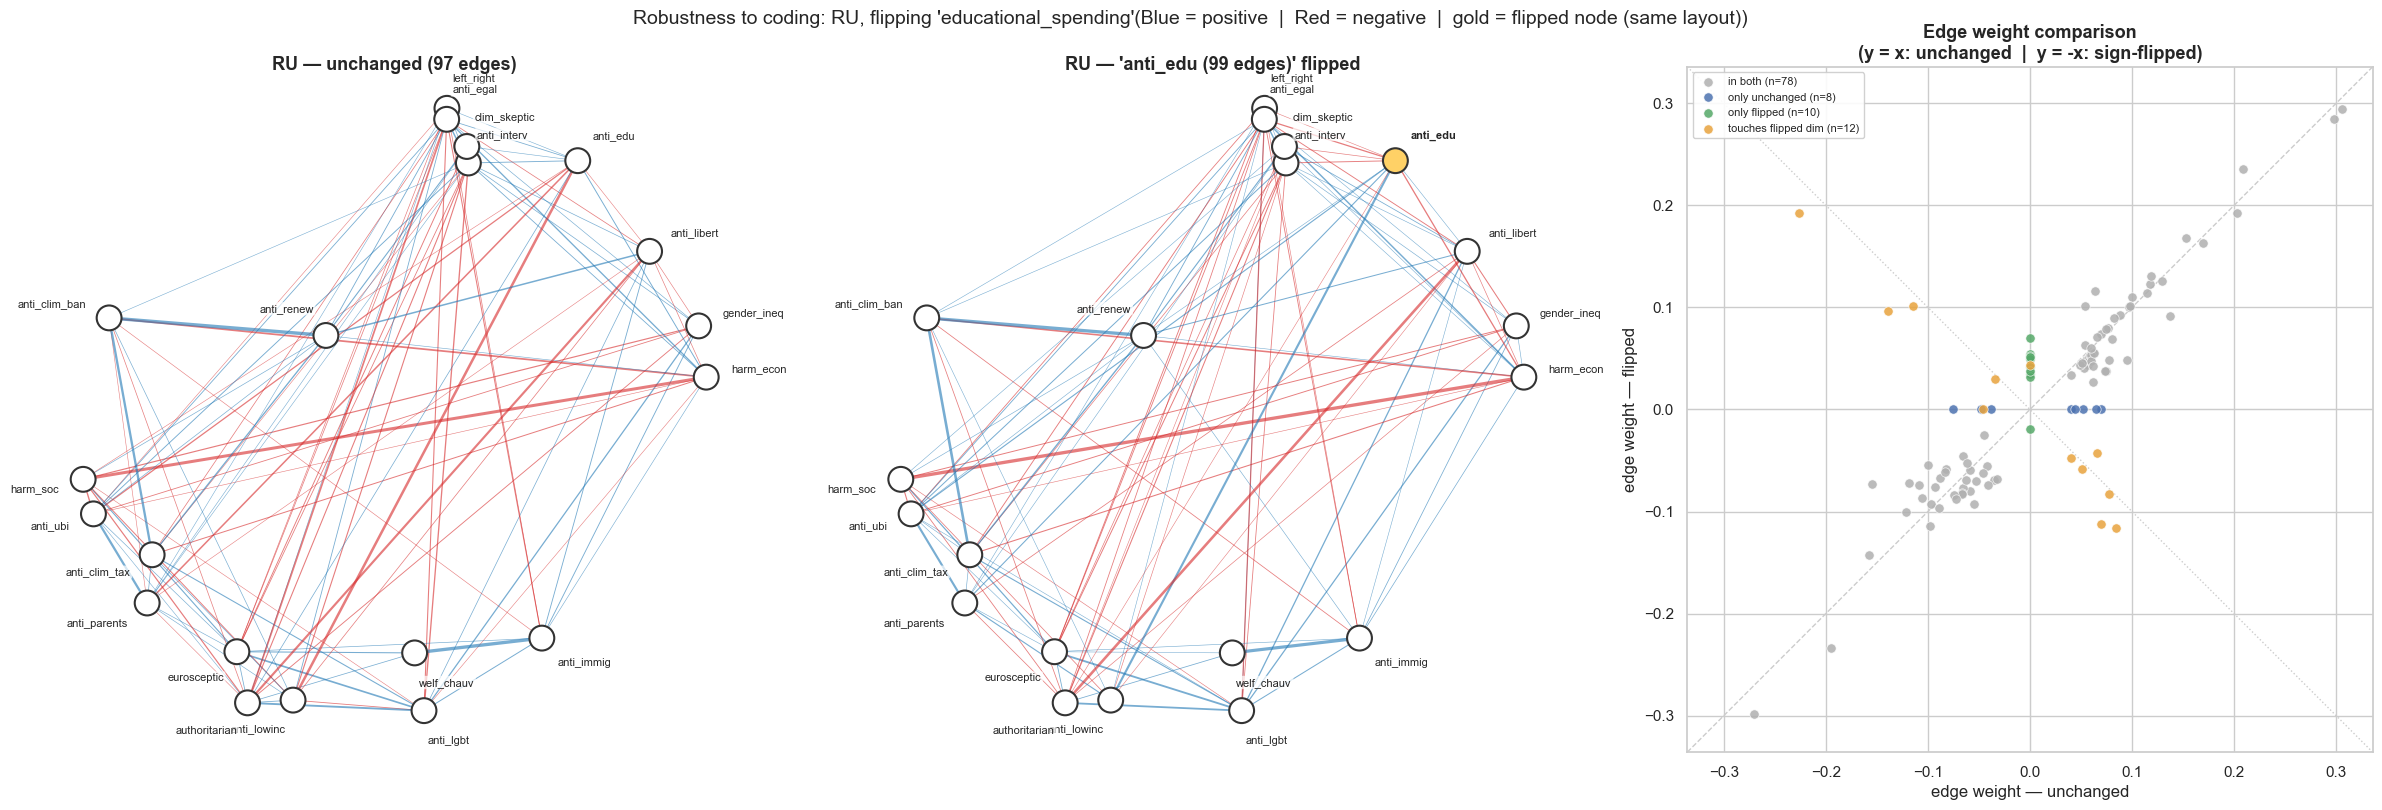

In [ ]:
# --- Pick a country and the dimension whose coding was flipped ---
COUNTRY = "RU"
DIMENSION = "educational_spending"   # any of the 20 belief dimensions

# Long belief names -> short labels (matches the plotting scripts in ../src)
SHORT_LABELS = {
    "left_right_identification": "left_right", "gender_inequality": "gender_ineq",
    "anti_lgbt": "anti_lgbt", "euroscepticism": "eurosceptic",
    "anti_immigration": "anti_immig", "anti_egalitarianism": "anti_egal",
    "benefits_harm_economy": "harm_econ", "benefits_harm_society": "harm_soc",
    "welfare_chauvinism": "welf_chauv", "anti_economic_interventionism": "anti_interv",
    "anti_social_benefits_low_income": "anti_lowinc",
    "anti_social_benefits_parents": "anti_parents",
    "educational_spending": "anti_edu", "anti_basic_income": "anti_ubi",
    "anti_climate_change_taxes": "anti_clim_tax",
    "anti_climate_change_renewables": "anti_renew",
    "anti_climate_ban_appliances": "anti_clim_ban", "climate_skepticism": "clim_skeptic",
    "authoritarianism": "authoritarian", "anti_libertarianism": "anti_libert",
}


def gt_to_nx(g):
    """Convert a graph-tool belief network (belief vp, weight ep) to networkx,
    with nodes keyed by belief name."""
    beliefs, weights = g.vp["belief"], g.ep["weight"]
    G = nx.Graph()
    for v in g.vertices():
        G.add_node(beliefs[v])
    for e in g.edges():
        G.add_edge(beliefs[e.source()], beliefs[e.target()], weight=weights[e])
    return G


def draw_belief_network(G, pos, ax, title, highlight=None):
    """Draw G at the given positions. Blue = positive, red = negative edge;
    width ~ |weight|. `highlight` node is drawn in gold."""
    ax.set_aspect("equal")
    ax.axis("off")

    for u, v, d in G.edges(data=True):
        w = d["weight"]
        color = "#d62728" if w < 0 else "#1f77b4"
        lw = np.clip(abs(w) * 8, 0.4, 4.0)
        ax.plot([pos[u][0], pos[v][0]], [pos[u][1], pos[v][1]],
                color=color, linewidth=lw, alpha=0.6, zorder=1,
                solid_capstyle="round")

    nodes = list(G.nodes())
    coords = np.array([pos[n] for n in nodes])
    face = ["#ffd166" if n == highlight else "white" for n in nodes]
    ax.scatter(coords[:, 0], coords[:, 1], s=320, c=face,
               edgecolors="#333333", linewidths=1.5, zorder=2)

    # Radially offset labels so they clear the node markers.
    cx, cy = coords[:, 0].mean(), coords[:, 1].mean()
    span = max(np.ptp(coords[:, 0]), np.ptp(coords[:, 1]))
    for n in nodes:
        x, y = pos[n]
        dx, dy = x - cx, y - cy
        norm = max(np.hypot(dx, dy), 1e-6)
        lx, ly = x + dx / norm * 0.04 * span, y + dy / norm * 0.04 * span
        ax.text(lx, ly, SHORT_LABELS.get(n, n), fontsize=8,
                ha="left" if dx >= 0 else "right",
                va="bottom" if dy >= 0 else "top", zorder=3,
                fontweight="bold" if n == highlight else "normal",
                bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.7))
    ax.set_title(title, fontsize=13, fontweight="bold")


def draw_edge_weight_scatter(ax, G_x, G_y, flipped_dim):
    """Scatter every edge in the union of G_x and G_y: x = weight in G_x,
    y = weight in G_y (0 when the edge is absent from that graph). Points are
    coloured by category, with edges touching the flipped dimension taking
    precedence.
    """
    # colour, xs, ys — insertion order controls legend order and z-stacking.
    cats = {
        "in both": ("#b0b0b0", [], []),
        "only unchanged": ("#4C72B0", [], []),
        "only flipped": ("#55A868", [], []),
        "touches flipped dim": ("#e8a33d", [], []),
    }

    edges = ({frozenset(e) for e in G_x.edges()}
             | {frozenset(e) for e in G_y.edges()})
    for e in edges:
        u, v = tuple(e)
        in_x, in_y = G_x.has_edge(u, v), G_y.has_edge(u, v)
        wx = G_x[u][v]["weight"] if in_x else 0.0
        wy = G_y[u][v]["weight"] if in_y else 0.0
        if flipped_dim in e:
            cat = "touches flipped dim"
        elif in_x and not in_y:
            cat = "only unchanged"
        elif in_y and not in_x:
            cat = "only flipped"
        else:
            cat = "in both"
        cats[cat][1].append(wx)
        cats[cat][2].append(wy)

    all_vals = [w for _, xs, ys in cats.values() for w in xs + ys]
    lim = (max((abs(v) for v in all_vals), default=1) or 1) * 1.1

    ax.plot([-lim, lim], [-lim, lim], ls="--", lw=1, color="#cccccc", zorder=0)  # y = x
    ax.plot([-lim, lim], [lim, -lim], ls=":", lw=1, color="#cccccc", zorder=0)   # y = -x
    ax.axhline(0, lw=0.8, color="#dddddd", zorder=0)
    ax.axvline(0, lw=0.8, color="#dddddd", zorder=0)

    for label, (color, xs, ys) in cats.items():
        if xs:
            ax.scatter(xs, ys, s=45, c=color, edgecolors="white", linewidths=0.5,
                       alpha=0.85, label=f"{label} (n={len(xs)})", zorder=2)

    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_aspect("equal")
    ax.set_xlabel("edge weight — unchanged")
    ax.set_ylabel("edge weight — flipped")
    ax.set_title("Edge weight comparison\n(y = x: unchanged  |  y = -x: sign-flipped)",
                 fontsize=13, fontweight="bold")
    ax.legend(fontsize=8, loc="best", framealpha=0.9)


g_unchanged = unchanged_graphs[COUNTRY]
g_flipped = one_dim_graphs[f"{COUNTRY}_{DIMENSION}_flipped"]

G_unchanged = gt_to_nx(g_unchanged)
G_flipped = gt_to_nx(g_flipped)

# Layout computed once from the UNCHANGED graph, reused for both subplots so
# node positions are identical.
pos = nx.spring_layout(G_unchanged, seed=42, k=1.2, iterations=500, weight="weight")

fig, axes = plt.subplots(1, 3, figsize=(24, 8))
draw_belief_network(G_unchanged, pos, axes[0], f"{COUNTRY} — unchanged ({G_unchanged.number_of_edges()} edges)")
draw_belief_network(G_flipped, pos, axes[1],
                    f"{COUNTRY} — '{SHORT_LABELS.get(DIMENSION, DIMENSION)}' flipped ({G_flipped.number_of_edges()} edges)",
                    highlight=DIMENSION)
draw_edge_weight_scatter(axes[2], G_unchanged, G_flipped, DIMENSION)
fig.suptitle(
    f"Robustness to coding: {COUNTRY}, flipping '{DIMENSION}'"
    "(Blue = positive  |  Red = negative  |  gold = flipped node (same layout))",
    fontsize=14,
)

fig.savefig(f"../output/figures/robustness_{COUNTRY}_{DIMENSION}.pdf", bbox_inches="tight")
plt.tight_layout()
plt.show()


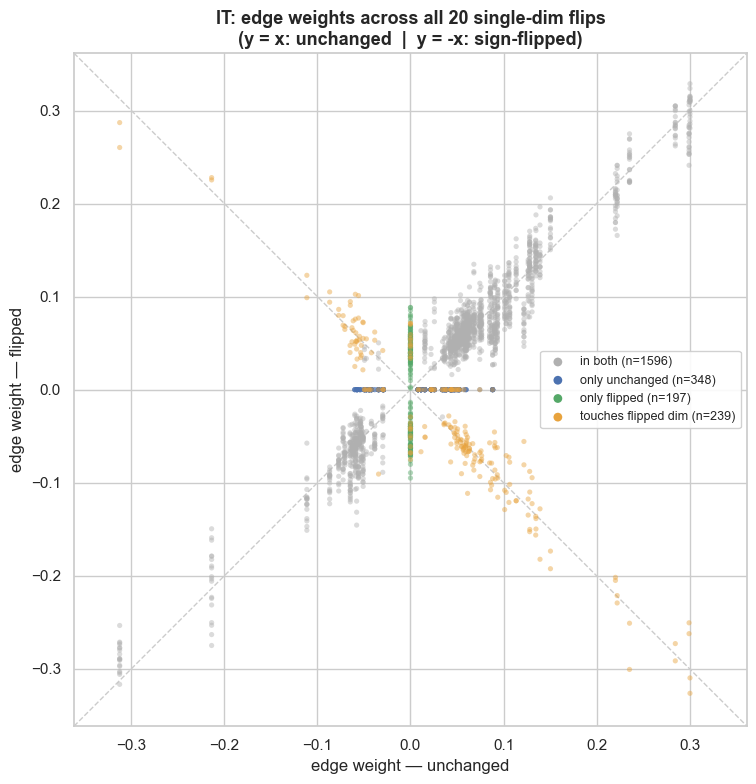

In [22]:
# Aggregate edge-weight comparison over ALL one-dimension flips for one country.
# Same scatter as the third panel above, but pooling every (unchanged vs flipped)
# edge across all 20 single-dimension flips. "touches flipped dim" means the edge
# is incident to the dimension flipped in that particular comparison.
# (Reuses gt_to_nx from the cell above — run it first.)
COUNTRY = "IT"

G_unchanged = gt_to_nx(unchanged_graphs[COUNTRY])

prefix, suffix = f"{COUNTRY}_", "_flipped"
flip_keys = sorted(k for k in one_dim_graphs
                   if k.startswith(prefix) and k.endswith(suffix))

# colour, xs, ys — insertion order controls legend order and z-stacking.
cats = {
    "in both": ("#b0b0b0", [], []),
    "only unchanged": ("#4C72B0", [], []),
    "only flipped": ("#55A868", [], []),
    "touches flipped dim": ("#e8a33d", [], []),
}

for key in flip_keys:
    dim = key[len(prefix):-len(suffix)]          # the single dimension flipped
    G_flip = gt_to_nx(one_dim_graphs[key])
    edges = ({frozenset(e) for e in G_unchanged.edges()}
             | {frozenset(e) for e in G_flip.edges()})
    for e in edges:
        u, v = tuple(e)
        in_u, in_f = G_unchanged.has_edge(u, v), G_flip.has_edge(u, v)
        wx = G_unchanged[u][v]["weight"] if in_u else 0.0
        wy = G_flip[u][v]["weight"] if in_f else 0.0
        if dim in e:                              # edge incident to the flipped dim
            cat = "touches flipped dim"
        elif in_u and not in_f:
            cat = "only unchanged"
        elif in_f and not in_u:
            cat = "only flipped"
        else:
            cat = "in both"
        cats[cat][1].append(wx)
        cats[cat][2].append(wy)

all_vals = [w for _, xs, ys in cats.values() for w in xs + ys]
lim = (max((abs(v) for v in all_vals), default=1) or 1) * 1.1

fig, ax = plt.subplots(figsize=(8, 8))
ax.plot([-lim, lim], [-lim, lim], ls="--", lw=1, color="#cccccc", zorder=0)  # y = x
ax.plot([-lim, lim], [lim, -lim], ls="--", lw=1, color="#cccccc", zorder=0)   # y = -x
ax.axhline(0, lw=0.8, color="#dddddd", zorder=0)
ax.axvline(0, lw=0.8, color="#dddddd", zorder=0)

for label, (color, xs, ys) in cats.items():
    if xs:
        ax.scatter(xs, ys, s=14, c=color, edgecolors="none", alpha=0.45,
                   label=f"{label} (n={len(xs)})", zorder=2)

ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.set_aspect("equal")
ax.set_xlabel("edge weight — unchanged")
ax.set_ylabel("edge weight — flipped")
ax.set_title(f"{COUNTRY}: edge weights across all {len(flip_keys)} single-dim flips\n"
             "(y = x: unchanged  |  y = -x: sign-flipped)",
             fontsize=13, fontweight="bold")
leg = ax.legend(fontsize=9, loc="best", framealpha=0.9)
for lh in leg.legend_handles:   # opaque, larger legend markers despite point alpha
    lh.set_alpha(1)
    lh.set_sizes([40])
plt.tight_layout()
plt.show()


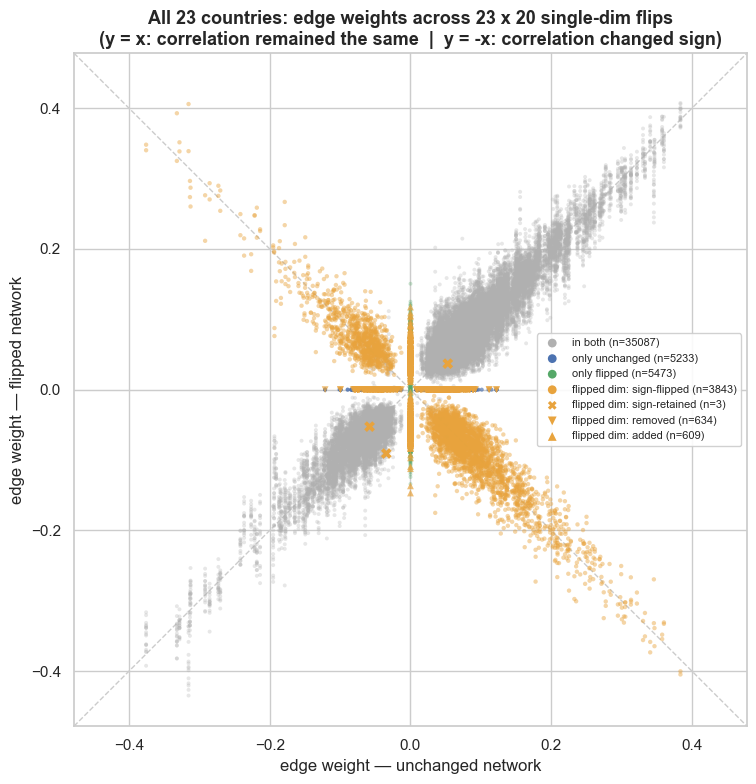

In [25]:
# Same aggregate over ALL countries (23 x 20 single-dimension flips), but the
# flipped-dimension edges are split into four subtypes, each with its own marker:
#   o sign-flipped (both graphs, opposite sign)   X sign-retained (both, same sign)
#   v removed (only unchanged, on x-axis)          ^ added (only flipped, on y-axis)
# (Reuses gt_to_nx from the one-dim viz cell above — run it first.)

# label: [colour, marker, size, alpha, xs, ys]
series = {
    "in both":                    ["#b0b0b0", "o",  8, 0.30, [], []],
    "only unchanged":             ["#4C72B0", "o",  8, 0.30, [], []],
    "only flipped":               ["#55A868", "o",  8, 0.30, [], []],
    "flipped dim: sign-flipped":  ["#e8a33d", "o", 10, 0.45, [], []],
    "flipped dim: sign-retained": ["#e8a33d", "X", 60, 1.00, [], []],
    "flipped dim: removed":       ["#e8a33d", "v", 24, 0.70, [], []],
    "flipped dim: added":         ["#e8a33d", "^", 24, 0.70, [], []],
}

countries = sorted(unchanged_graphs)
n_flips = 0
for country in countries:
    G_unchanged = gt_to_nx(unchanged_graphs[country])
    prefix, suffix = f"{country}_", "_flipped"
    flip_keys = sorted(k for k in one_dim_graphs
                       if k.startswith(prefix) and k.endswith(suffix))
    for key in flip_keys:
        dim = key[len(prefix):-len(suffix)]      # the single dimension flipped
        G_flip = gt_to_nx(one_dim_graphs[key])
        edges = ({frozenset(e) for e in G_unchanged.edges()}
                 | {frozenset(e) for e in G_flip.edges()})
        for e in edges:
            u, v = tuple(e)
            in_u, in_f = G_unchanged.has_edge(u, v), G_flip.has_edge(u, v)
            wx = G_unchanged[u][v]["weight"] if in_u else 0.0
            wy = G_flip[u][v]["weight"] if in_f else 0.0
            if dim in e:                          # edge incident to the flipped dim
                if in_u and in_f:
                    label = ("flipped dim: sign-flipped" if wx * wy < 0
                             else "flipped dim: sign-retained")
                elif in_u:
                    label = "flipped dim: removed"
                else:
                    label = "flipped dim: added"
            elif in_u and not in_f:
                label = "only unchanged"
            elif in_f and not in_u:
                label = "only flipped"
            else:
                label = "in both"
            series[label][4].append(wx)
            series[label][5].append(wy)
        n_flips += 1

all_vals = [w for s in series.values() for w in s[4] + s[5]]
lim = (max((abs(v) for v in all_vals), default=1) or 1) * 1.1

fig, ax = plt.subplots(figsize=(8, 8))
ax.plot([-lim, lim], [-lim, lim], ls="--", lw=1, color="#cccccc", zorder=0)  # y = x
ax.plot([-lim, lim], [lim, -lim], ls="--", lw=1, color="#cccccc", zorder=0)  # y = -x
ax.axhline(0, lw=0.8, color="#dddddd", zorder=0)
ax.axvline(0, lw=0.8, color="#dddddd", zorder=0)

for label, (color, marker, size, alpha, xs, ys) in series.items():
    if xs:
        ax.scatter(xs, ys, s=size, c=color, marker=marker, edgecolors="none",
                   alpha=alpha, label=f"{label} (n={len(xs)})", zorder=2)

ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.set_aspect("equal")
ax.set_xlabel("edge weight — unchanged network")
ax.set_ylabel("edge weight — flipped network")
ax.set_title(f"All {len(countries)} countries: edge weights across "
             "23 x 20 single-dim flips\n"
             "(y = x: correlation remained the same  |  y = -x: correlation changed sign)",
             fontsize=13, fontweight="bold")
leg = ax.legend(fontsize=8, loc="best", framealpha=0.9)
for lh in leg.legend_handles:   # opaque, larger legend markers despite point alpha
    lh.set_alpha(1)
    lh.set_sizes([40])
plt.tight_layout()
plt.show()


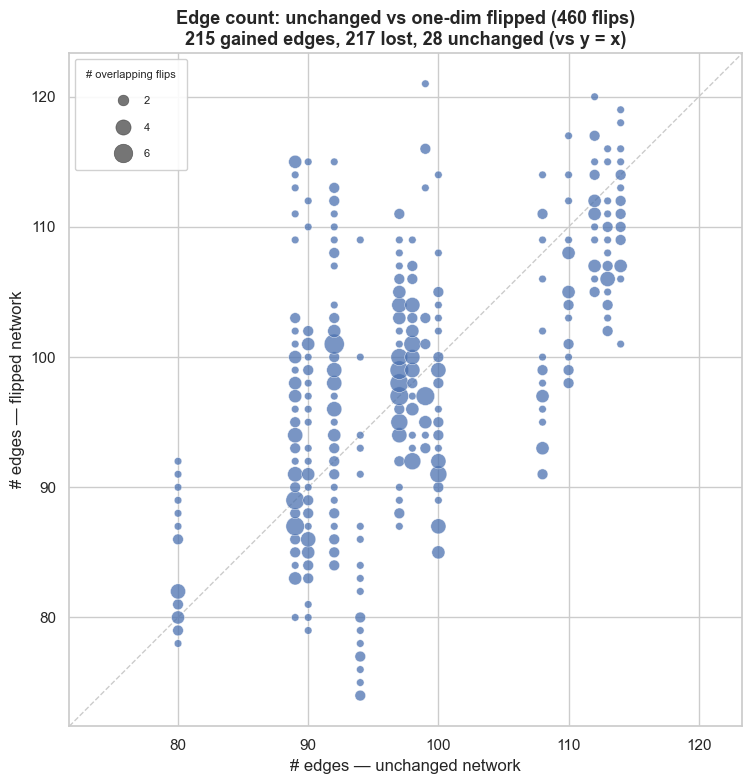

In [27]:
# Edge count: unchanged vs one-dim-flipped network — one point per
# (country, flipped dimension), pooled over all 23 countries x 20 flips.
# Marker size scales with the number of flips landing on that exact coordinate.
# (Uses the loaded graph-tool graphs directly; num_edges needs no conversion.)
xs, ys = [], []
for country in sorted(unchanged_graphs):
    n_unchanged = unchanged_graphs[country].num_edges()
    prefix, suffix = f"{country}_", "_flipped"
    for key in sorted(k for k in one_dim_graphs
                      if k.startswith(prefix) and k.endswith(suffix)):
        xs.append(n_unchanged)
        ys.append(one_dim_graphs[key].num_edges())

xs = np.array(xs)
ys = np.array(ys)

# Collapse identical (unchanged, flipped) coordinates and count the overlaps.
coords, counts = np.unique(np.column_stack([xs, ys]), axis=0, return_counts=True)
SIZE_PER_POINT = 30

lo, hi = min(xs.min(), ys.min()), max(xs.max(), ys.max())
pad = 0.05 * (hi - lo)

fig, ax = plt.subplots(figsize=(8, 8))
ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], ls="--", lw=1,
        color="#cccccc", zorder=0)  # y = x
sc = ax.scatter(coords[:, 0], coords[:, 1], s=counts * SIZE_PER_POINT,
                c="#4C72B0", edgecolors="white", linewidths=0.4,
                alpha=0.75, zorder=2)

# Size legend: marker area -> number of overlapping flips.
handles, labels = sc.legend_elements(prop="sizes", num=4, alpha=0.6,
                                     func=lambda s: s / SIZE_PER_POINT)
ax.legend(handles, labels, title="# overlapping flips", loc="upper left",
          fontsize=8, title_fontsize=8, labelspacing=1.3, framealpha=0.9,
          borderpad=1)

ax.set_xlim(lo - pad, hi + pad)
ax.set_ylim(lo - pad, hi + pad)
ax.set_aspect("equal")
ax.set_xlabel("# edges — unchanged network")
ax.set_ylabel("# edges — flipped network")
n_more = int((ys > xs).sum())
n_fewer = int((ys < xs).sum())
n_same = int((ys == xs).sum())
ax.set_title(f"Edge count: unchanged vs one-dim flipped ({len(xs)} flips)\n"
             f"{n_more} gained edges, {n_fewer} lost, {n_same} unchanged (vs y = x)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


# Analyze the robustness to change in coding of five belief dimensions

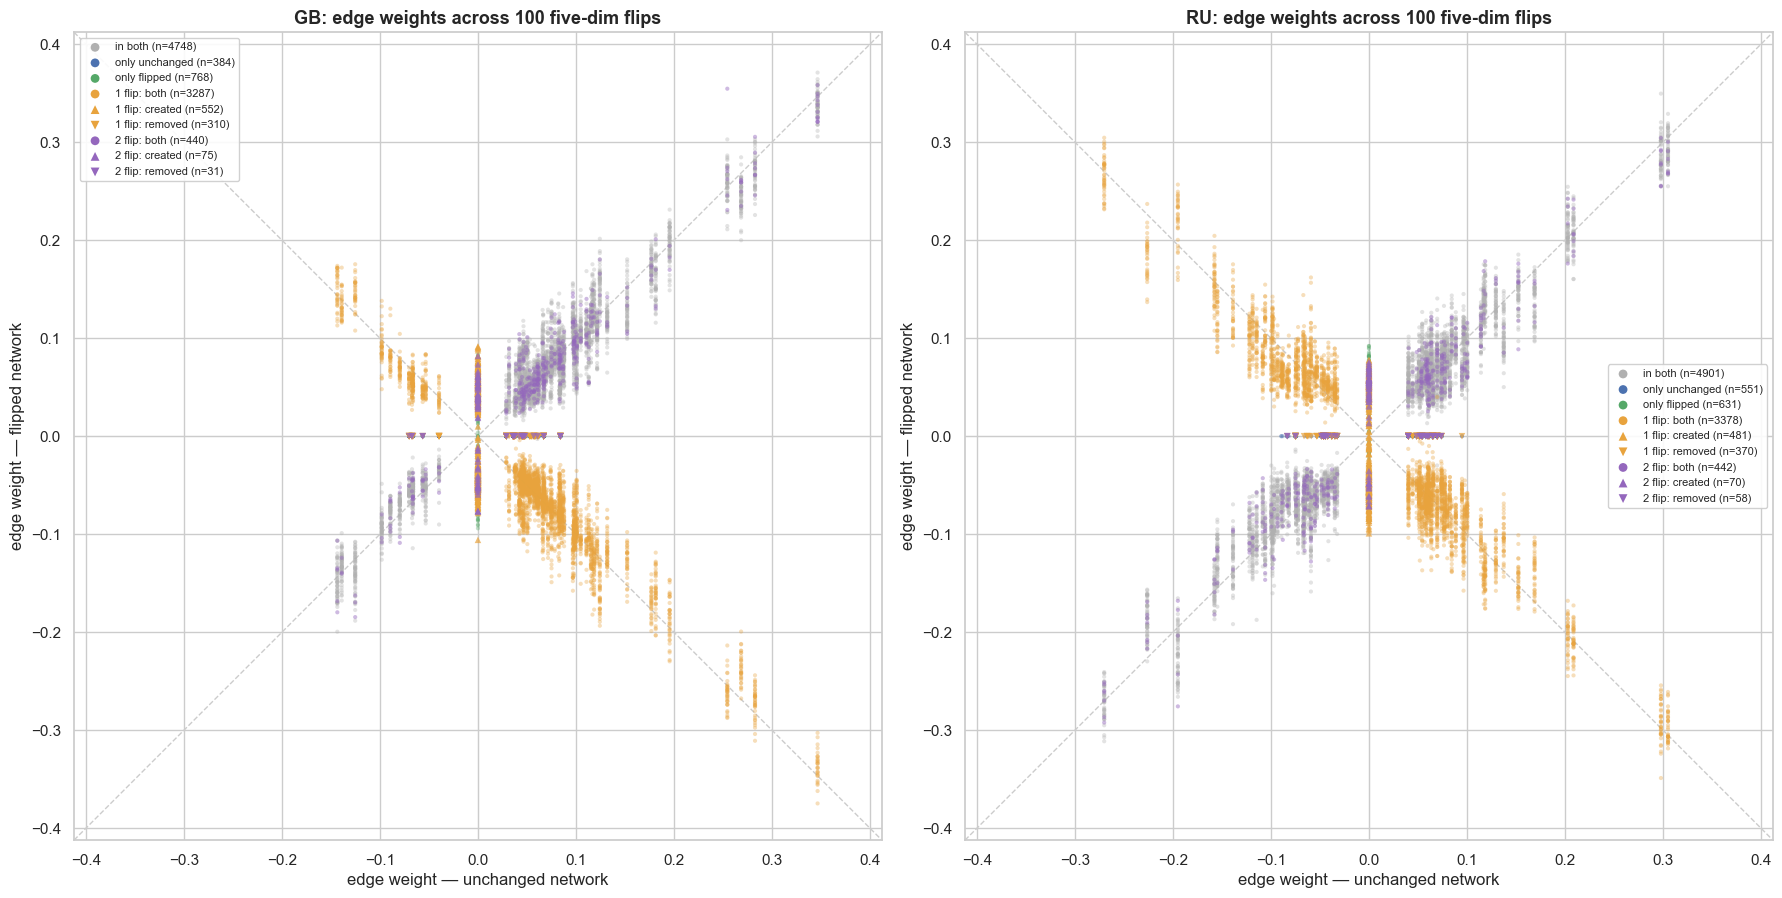

In [30]:
# Five-dim flips: edge-weight scatter, aggregated PER COUNTRY (GB and RU shown
# separately, not pooled). Colour = how many of the edge's two endpoints are
# flipped dimensions (1 -> expect y=-x, 2 -> expect y=x); marker = presence:
#   o both networks    ^ created (only flipped, y-axis)    v removed (only unchanged, x-axis)
# (Reuses gt_to_nx from the one-dim viz cell above — run it first.)

FIVE_COUNTRIES = ["GB", "RU"]


def five_dim_series(country):
    """Pool every unchanged-vs-flipped edge over all of a country's flip samples."""
    G_unchanged = gt_to_nx(unchanged_graphs[country])
    # label -> [colour, marker, size, alpha, xs, ys]
    series = {
        "in both":         ["#b0b0b0", "o",  9, 0.35, [], []],
        "only unchanged":  ["#4C72B0", "o",  9, 0.35, [], []],
        "only flipped":    ["#55A868", "o",  9, 0.35, [], []],
        "1 flip: both":    ["#e8a33d", "o",  9, 0.35, [], []],
        "1 flip: created": ["#e8a33d", "^", 22, 0.70, [], []],
        "1 flip: removed": ["#e8a33d", "v", 22, 0.70, [], []],
        "2 flip: both":    ["#9467bd", "o",  9, 0.45, [], []],
        "2 flip: created": ["#9467bd", "^", 22, 0.70, [], []],
        "2 flip: removed": ["#9467bd", "v", 22, 0.70, [], []],
    }
    for key, g in five_dim_graphs[country].items():
        flipped = set(five_dim_flipped_dims[country][key])   # this sample's 5 dims
        G_flip = gt_to_nx(g)
        edges = ({frozenset(e) for e in G_unchanged.edges()}
                 | {frozenset(e) for e in G_flip.edges()})
        for e in edges:
            u, v = tuple(e)
            in_u, in_f = G_unchanged.has_edge(u, v), G_flip.has_edge(u, v)
            wx = G_unchanged[u][v]["weight"] if in_u else 0.0
            wy = G_flip[u][v]["weight"] if in_f else 0.0
            n_touch = len(e & flipped)                        # 0, 1, or 2
            if n_touch in (1, 2):
                tag = "1 flip" if n_touch == 1 else "2 flip"
                if in_u and in_f:
                    label = f"{tag}: both"
                elif in_f:
                    label = f"{tag}: created"
                else:
                    label = f"{tag}: removed"
            elif in_u and not in_f:
                label = "only unchanged"
            elif in_f and not in_u:
                label = "only flipped"
            else:
                label = "in both"
            series[label][4].append(wx)
            series[label][5].append(wy)
    return series


series_by_country = {c: five_dim_series(c) for c in FIVE_COUNTRIES}

# Shared axis limit so the two countries are directly comparable.
all_vals = [w for s in series_by_country.values()
            for v in s.values() for w in v[4] + v[5]]
lim = (max((abs(v) for v in all_vals), default=1) or 1) * 1.1

fig, axes = plt.subplots(1, 2, figsize=(18, 9))
for ax, country in zip(axes, FIVE_COUNTRIES):
    ax.plot([-lim, lim], [-lim, lim], ls="--", lw=1, color="#cccccc", zorder=0)  # y = x
    ax.plot([-lim, lim], [lim, -lim], ls="--", lw=1, color="#cccccc", zorder=0)  # y = -x
    ax.axhline(0, lw=0.8, color="#dddddd", zorder=0)
    ax.axvline(0, lw=0.8, color="#dddddd", zorder=0)
    for label, (color, marker, size, alpha, xs, ys) in series_by_country[country].items():
        if xs:
            ax.scatter(xs, ys, s=size, c=color, marker=marker, edgecolors="none",
                       alpha=alpha, label=f"{label} (n={len(xs)})", zorder=2)
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_aspect("equal")
    ax.set_xlabel("edge weight — unchanged network")
    ax.set_ylabel("edge weight — flipped network")
    n = len(five_dim_graphs[country])
    ax.set_title(f"{country}: edge weights across {n} five-dim flips",
                 fontsize=13, fontweight="bold")
    leg = ax.legend(fontsize=8, loc="best", framealpha=0.9)
    for lh in leg.legend_handles:
        lh.set_alpha(1)
        lh.set_sizes([40])

# fig.suptitle("Five-dimension flips: 1 flipped endpoint -> sign flips (y = -x)  |  "
            #  "2 flipped endpoints -> sign retained (y = x)", fontsize=13)
plt.tight_layout()
plt.show()


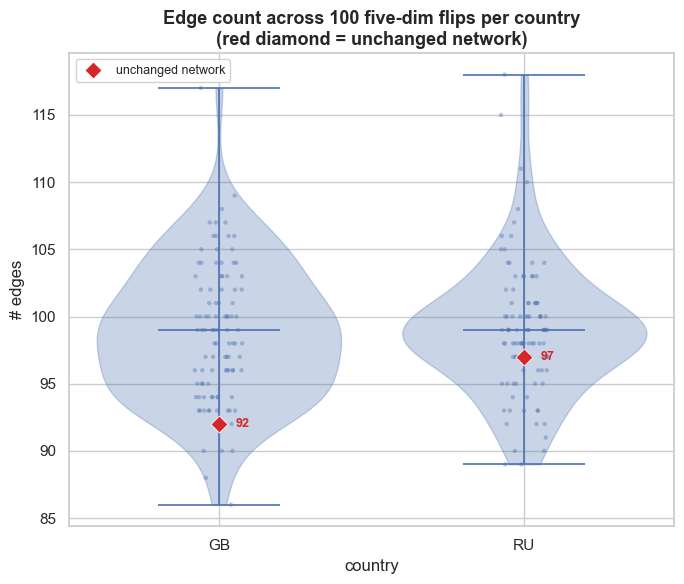

In [29]:
# Edge-count distribution across the 100 five-dim flips, one violin per country,
# with the unchanged network's edge count marked (red diamond).
FIVE_COUNTRIES = ["GB", "RU"]

edge_counts = {c: [g.num_edges() for g in five_dim_graphs[c].values()]
               for c in FIVE_COUNTRIES}
unchanged_counts = {c: unchanged_graphs[c].num_edges() for c in FIVE_COUNTRIES}

positions = np.arange(1, len(FIVE_COUNTRIES) + 1)

fig, ax = plt.subplots(figsize=(7, 6))
parts = ax.violinplot([edge_counts[c] for c in FIVE_COUNTRIES], positions=positions,
                      widths=0.8, showmedians=True, showextrema=True)
for body in parts["bodies"]:
    body.set_facecolor("#4C72B0")
    body.set_edgecolor("#4C72B0")
    body.set_alpha(0.30)
for key in ("cmedians", "cmins", "cmaxes", "cbars"):
    if key in parts:
        parts[key].set_color("#4C72B0")
        parts[key].set_linewidth(1.2)

# Individual flip samples (light jittered strip) and the unchanged-network value.
rng = np.random.default_rng(42)
for pos, c in zip(positions, FIVE_COUNTRIES):
    ys = edge_counts[c]
    ax.scatter(pos + rng.uniform(-0.08, 0.08, size=len(ys)), ys,
               s=10, color="#4C72B0", alpha=0.4, edgecolors="none", zorder=2)
    ax.scatter([pos], [unchanged_counts[c]], marker="D", s=75, color="#d62728",
               edgecolors="white", linewidths=0.6, zorder=5,
               label="unchanged network" if pos == positions[0] else None)
    ax.annotate(str(unchanged_counts[c]), (pos, unchanged_counts[c]),
                textcoords="offset points", xytext=(12, 0), va="center",
                fontsize=9, color="#d62728", fontweight="bold")

ax.set_xticks(positions)
ax.set_xticklabels(FIVE_COUNTRIES)
ax.set_xlabel("country")
ax.set_ylabel("# edges")
ax.set_title("Edge count across 100 five-dim flips per country\n"
             "(red diamond = unchanged network)", fontsize=13, fontweight="bold")
ax.legend(fontsize=9, loc="best", framealpha=0.9)
plt.tight_layout()
plt.show()
